# 🚀 TenderPilot — ML Model for EU Public Tender Prediction

**Goal:** Predict whether a public tender will result in a contract award.

**Dataset:** TED (Tenders Electronic Daily) — Contract Forming Cycle 2018–2023

**ML Task:** Binary Classification → awarded (1) vs. not awarded (0)

 ## Step-by-Step Overview

 1. **Setup & Imports** — Load libraries
 2. **Data Loading** — Efficient loading of 3.6GB dataset
 3. **Exploratory Data Analysis (EDA)** — Understand the data
 4. **Feature Engineering** — Build features for the model
 5. **Train/Test Split** — Split the data
 6. **Baseline Model** — Logistic Regression
 7. **Advanced Model** — XGBoost
 8. **Evaluation & Comparison** — How good are our models?
 9. **Feature Importance** — What drives the prediction?
 10. **Cross-Validation** — How stable is the model?
 11. **Threshold Tuning** — Optimize decision boundary
 12. **Business KPIs** — Real-world impact simulation
 13. **Optuna Hyperparameter Tuning** — Automated optimization
 14. **Conclusion & Next Steps** — Summary and SaaS outlook

 ---
 ## 1. Setup & Imports

 First, we load all the libraries we need. If any are missing: `pip install <name>`

In [1]:
# %%
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, recall_score,
    precision_score, precision_recall_curve, fbeta_score
)

# Settings
pd.set_option('display.max_columns', 70)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

print('✅ All imports loaded successfully!')

# XGBoost
try:
    from xgboost import XGBClassifier
    print('✅ XGBoost loaded')
except ImportError:
    print('⚠️ XGBoost not installed. Run: pip install xgboost')

✅ All imports loaded successfully!
✅ XGBoost loaded


 ---
 ## 2. Data Loading

 The CSV file is **3.6 GB** (~7.7M rows). We load the **first 500,000 rows** with only
 the relevant columns to keep memory usage low and iteration fast.

 > 💡 **Why load specific columns?** By selecting only 28 of 64 columns and defining
 > data types upfront, we reduce RAM usage by ~60% and load 5× faster.

In [2]:
# %%
DTYPES = {
    'ID_NOTICE_CN': 'float64',
    'YEAR': 'float32',
    'CANCELLED': 'float64',
    'FUTURE_CAN_ID': 'float64',
    'ISO_COUNTRY_CODE': str,
    'CAE_TYPE': str,
    'MAIN_ACTIVITY': str,
    'TYPE_OF_CONTRACT': str,
    'TAL_LOCATION_NUTS': str,
    'B_FRA_AGREEMENT': str,
    'B_DYN_PURCH_SYST': str,
    'CPV': str,
    'B_GPA': str,
    'LOTS_NUMBER': 'float32',
    'VALUE_EURO': 'float64',
    'VALUE_EURO_FIN_1': 'float64',
    'VALUE_EURO_FIN_2': 'float64',
    'B_EU_FUNDS': str,
    'B_RENEWALS': str,
    'B_OPTIONS': str,
    'DURATION': 'float32',
    'TOP_TYPE': str,
    'CRIT_CODE': str,
    'CRIT_PRICE_WEIGHT': str,
    'B_ELECTRONIC_AUCTION': str,
    'B_RECURRENT_PROCUREMENT': str,
}

USE_COLS = [
    'ID_NOTICE_CN', 'YEAR', 'CANCELLED', 'FUTURE_CAN_ID',
    'ISO_COUNTRY_CODE', 'CAE_TYPE', 'MAIN_ACTIVITY',
    'TYPE_OF_CONTRACT', 'TAL_LOCATION_NUTS',
    'B_FRA_AGREEMENT', 'B_DYN_PURCH_SYST',
    'CPV', 'B_GPA', 'LOTS_NUMBER',
    'VALUE_EURO', 'VALUE_EURO_FIN_1', 'VALUE_EURO_FIN_2',
    'B_EU_FUNDS', 'B_RENEWALS', 'B_OPTIONS',
    'DURATION', 'TOP_TYPE', 'CRIT_CODE', 'CRIT_PRICE_WEIGHT',
    'B_ELECTRONIC_AUCTION', 'B_RECURRENT_PROCUREMENT',
    'DT_DISPATCH', 'DT_APPLICATIONS'
]

print('Loading 500,000 rows from 3.6GB CSV...')

df_raw_r =  pd.read_csv(
    '/Users/edu/Edu/testproject/tenderpilot_data/data/export_CFC_2018_2023.csv',
    nrows=500,
    low_memory=False
)

df_raw = pd.read_csv(
    '/Users/edu/Edu/testproject/tenderpilot_data/data/export_CFC_2018_2023.csv',
    usecols=USE_COLS,
    dtype={k: v for k, v in DTYPES.items() if k in USE_COLS},
    nrows=500_000,
    low_memory=False
)

print(f'✅ Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'💾 Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Loading 500,000 rows from 3.6GB CSV...
✅ Loaded: 500,000 rows × 28 columns
💾 Memory usage: 512.6 MB


In [14]:
# Quick look at the data
df_raw.head()

,ID_NOTICE_CN,YEAR,DT_DISPATCH,CANCELLED,FUTURE_CAN_ID,ISO_COUNTRY_CODE,CAE_TYPE,MAIN_ACTIVITY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,B_DYN_PURCH_SYST,CPV,B_GPA,LOTS_NUMBER,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2,B_OPTIONS,B_EU_FUNDS,B_RENEWALS,DURATION,TOP_TYPE,CRIT_CODE,CRIT_PRICE_WEIGHT,B_ELECTRONIC_AUCTION,DT_APPLICATIONS,B_RECURRENT_PROCUREMENT
0,20181.0,2018.0,22/12/17,0.0,2.021265e+09,BE,5,Health,S,BE10,Y,N,79200000,N,1.0,1.0,1.0,1.0,N,Y,Y,36.0,OPE,NaN,NaN,N,05/02/18,N
1,20181.0,2018.0,22/12/17,0.0,2.022329e+09,BE,5,Health,S,BE10,Y,N,79200000,N,1.0,1.0,1.0,1.0,N,Y,Y,36.0,OPE,NaN,NaN,N,05/02/18,N
2,20182.0,2018.0,22/12/17,0.0,2.018490e+09,LU,5,Other,S,LU000,Y,N,79530000,N,23.0,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,OPE,NaN,NaN,N,13/02/18,N
3,20182.0,2018.0,22/12/17,0.0,2.018490e+09,LU,5,Other,S,LU000,Y,N,79530000,N,23.0,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,OPE,NaN,NaN,N,13/02/18,N
4,20182.0,2018.0,22/12/17,0.0,2.018490e+09,LU,5,Other,S,LU000,Y,N,79530000,N,23.0,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,OPE,NaN,NaN,N,13/02/18,N


In [3]:
df_raw_r.head()

,ID_NOTICE_CN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,FUTURE_CAN_ID,FUTURE_CAN_ID_ESTIMATED,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,ISO_COUNTRY_CODE,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_SINGLE_OPERATOR,FRA_NUMBER_OPERATORS,FRA_NUMBER_MAX_OPERATORS,B_DYN_PURCH_SYST,CPV,ID_LOT,ADDITIONAL_CPVS,B_GPA,LOTS_NUMBER,LOTS_SUBMISSION,B_VARIANTS,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2,B_OPTIONS,B_EU_FUNDS,B_RENEWALS,DURATION,CONTRACT_START,CONTRACT_COMPLETION,TOP_TYPE,B_ACCELERATED,ENV_OPERATORS,ENV_MIN_OPERATORS,ENV_MAX_OPERATORS,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,DT_APPLICATIONS,B_LANGUAGE_ANY_EC,ADMIN_LANGUAGES_TENDER,ADMIN_OTHER_LANGUAGES_TENDER,B_RECURRENT_PROCUREMENT
0,20181,ted.europa.eu/udl?uri=TED:NOTICE:1-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.021265e+09,0,N,Innovative Medicines Initiative 2 Joint Undert...,NaN,IMI2 JU — TO 56 1049 Brussels; Belgium,Brussels,1060,BE,N,NaN,5,AG,Health,Y,Y,N,S,BE10,Y,NaN,N,3.0,3.0,N,79200000,NaN,79210000,N,1,NaN,N,1.0,1.0,1.0,N,Y,Y,36.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,05/02/18,NaN,BG|CS|DA|DE|EL|EN|ES|ET|FI|FR|GA|HR|HU|IT|LT|L...,NaN,N
1,20181,ted.europa.eu/udl?uri=TED:NOTICE:1-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.022329e+09,0,N,Innovative Medicines Initiative 2 Joint Undert...,NaN,IMI2 JU — TO 56 1049 Brussels; Belgium,Brussels,1060,BE,N,NaN,5,AG,Health,Y,Y,N,S,BE10,Y,NaN,N,3.0,3.0,N,79200000,NaN,79210000,N,1,NaN,N,1.0,1.0,1.0,N,Y,Y,36.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,05/02/18,NaN,BG|CS|DA|DE|EL|EN|ES|ET|FI|FR|GA|HR|HU|IT|LT|L...,NaN,N
2,20182,ted.europa.eu/udl?uri=TED:NOTICE:2-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.018490e+09,0,N,Translation Centre for the Bodies of the Europ...,NaN,"Bâtiment Drosbach 12E, rue Guillaume Kroll",Luxembourg,L-1882 -Luxembourg,LU,N,NaN,5,AG,Other,Y,N,Y,S,LU000,Y,NaN,N,15.0,15.0,N,79530000,1.0,79530000,N,23,NaN,N,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,13/02/18,NaN,EN|BG|DA|DE|EL|ET|FI|FR|GA|HR|HU|IT|LV|LT|MT|N...,NaN,N
3,20182,ted.europa.eu/udl?uri=TED:NOTICE:2-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.018490e+09,0,N,Translation Centre for the Bodies of the Europ...,NaN,"Bâtiment Drosbach 12E, rue Guillaume Kroll",Luxembourg,L-1882 -Luxembourg,LU,N,NaN,5,AG,Other,Y,N,Y,S,LU000,Y,NaN,N,15.0,15.0,N,79530000,10.0,79530000,N,23,NaN,N,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,13/02/18,NaN,EN|BG|DA|DE|EL|ET|FI|FR|GA|HR|HU|IT|LV|LT|MT|N...,NaN,N
4,20182,ted.europa.eu/udl?uri=TED:NOTICE:2-2018:TEXT:E...,2018,2,22/12/17,R209.S2,0,1,2.018490e+09,0,N,Translation Centre for the Bodies of the Europ...,NaN,"Bâtiment Drosbach 12E, rue Guillaume Kroll",Luxembourg,L-1882 -Luxembourg,LU,N,NaN,5,AG,Other,Y,N,Y,S,LU000,Y,NaN,N,15.0,15.0,N,79530000,11.0,79530000,N,23,NaN,N,2400000.0,2400000.0,2400000.0,N,N,Y,12.0,NaN,NaN,OPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,13/02/18,NaN,EN|BG|DA|DE|EL|ET|FI|FR|GA|HR|HU|IT|LV|LT|MT|N...,NaN,N


In [15]:
# Data types and null values
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ID_NOTICE_CN             500000 non-null  float64
 1   YEAR                     500000 non-null  float32
 2   DT_DISPATCH              500000 non-null  object 
 3   CANCELLED                500000 non-null  float64
 4   FUTURE_CAN_ID            439928 non-null  float64
 5   ISO_COUNTRY_CODE         500000 non-null  object 
 6   CAE_TYPE                 500000 non-null  object 
 7   MAIN_ACTIVITY            499998 non-null  object 
 8   TYPE_OF_CONTRACT         500000 non-null  object 
 9   TAL_LOCATION_NUTS        494664 non-null  object 
 10  B_FRA_AGREEMENT          500000 non-null  object 
 11  B_DYN_PURCH_SYST         482304 non-null  object 
 12  CPV                      499999 non-null  object 
 13  B_GPA                    485830 non-null  object 
 14  LOTS

 ---
 ## 3. Exploratory Data Analysis (EDA)

 Before modeling, we need to understand the data.

 ### 3.1 Target Variable: Was the tender awarded?

=== Target Distribution ===
awarded
1    439928
0     60072
Name: count, dtype: int64

Award Rate: 88.0%


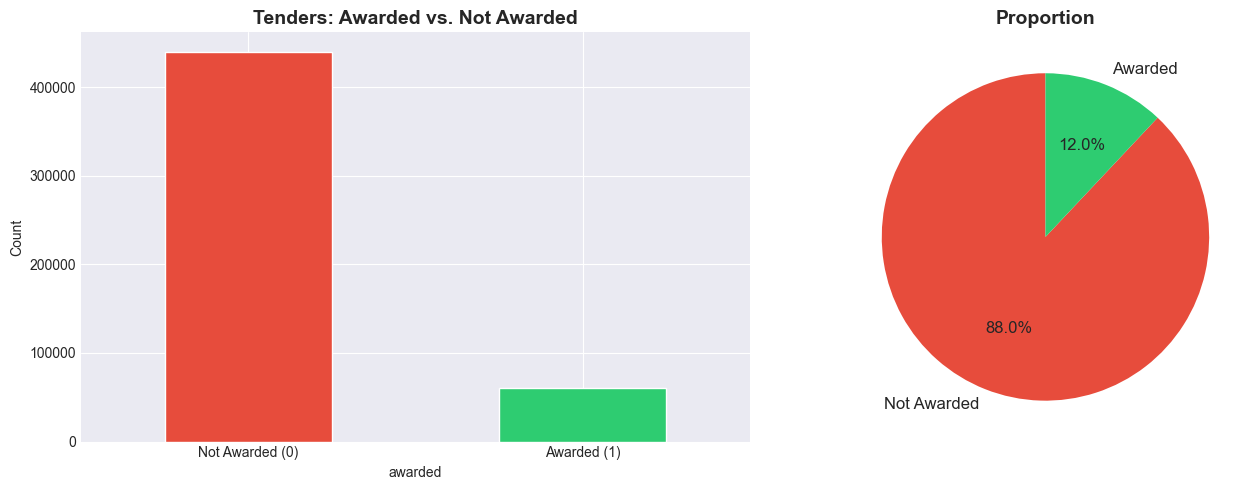

In [16]:
# Create target: Did the tender result in a contract award?
# FUTURE_CAN_ID != NaN means a Contract Award Notice exists
df_raw['awarded'] = df_raw['FUTURE_CAN_ID'].notna().astype(int)

print('=== Target Distribution ===')
print(df_raw['awarded'].value_counts())
print()
print(f"Award Rate: {df_raw['awarded'].mean()*100:.1f}%")

# %%
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#2ecc71']
df_raw['awarded'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white'
)
axes[0].set_title('Tenders: Awarded vs. Not Awarded', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Not Awarded (0)', 'Awarded (1)'], rotation=0)
axes[0].set_ylabel('Count')

df_raw['awarded'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colors,
    labels=['Not Awarded', 'Awarded'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 3.2 Distribution by Country

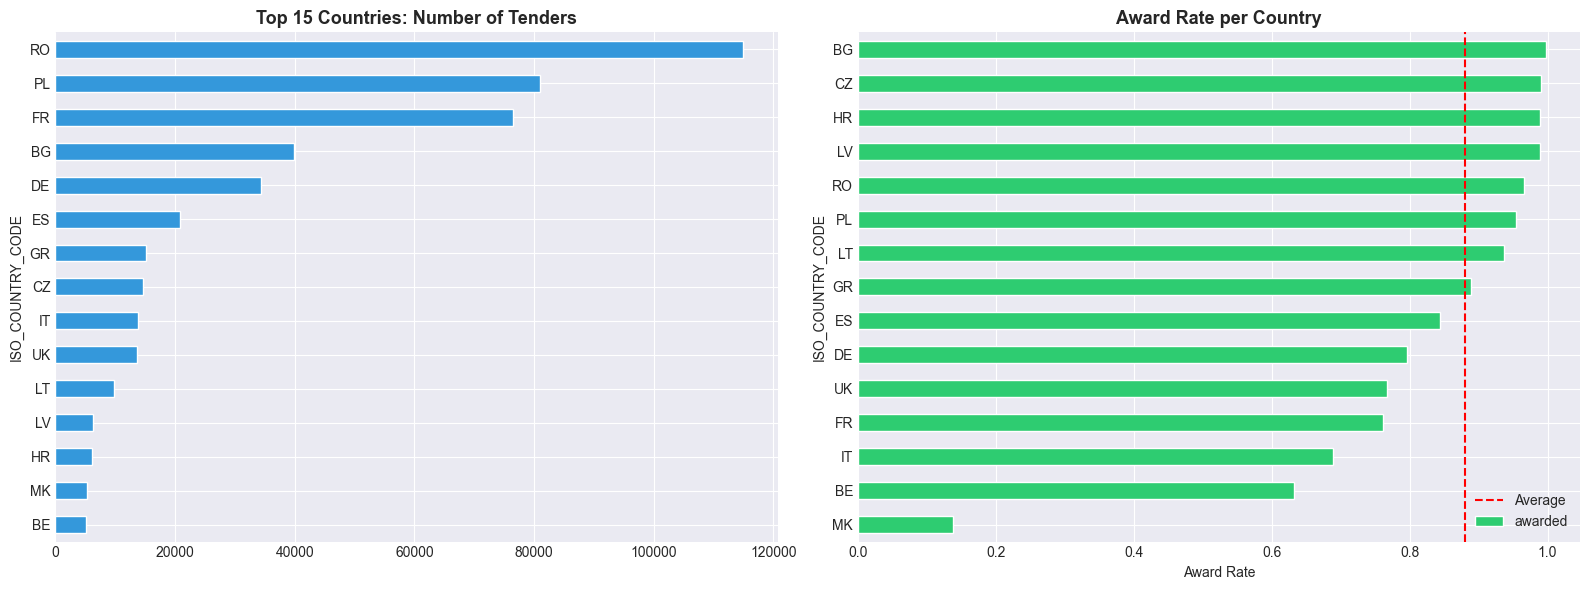

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_countries = df_raw['ISO_COUNTRY_CODE'].value_counts().head(15)
top_countries.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Top 15 Countries: Number of Tenders', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

award_by_country = (
    df_raw[df_raw['ISO_COUNTRY_CODE'].isin(top_countries.index)]
    .groupby('ISO_COUNTRY_CODE')['awarded'].mean()
    .sort_values(ascending=True)
)
award_by_country.plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Award Rate per Country', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Award Rate')
axes[1].axvline(x=df_raw['awarded'].mean(), color='red', linestyle='--', label='Average')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3 Contract Value Analysis

In [18]:
values = df_raw[df_raw['VALUE_EURO'] > 0]['VALUE_EURO']

print('=== Contract Values (EUR) ===')
print(values.describe())
print(f'\nMedian: {values.median():,.0f} EUR')
print(f'90th percentile: {values.quantile(0.9):,.0f} EUR')
print(f'99th percentile: {values.quantile(0.99):,.0f} EUR')

=== Contract Values (EUR) ===
count    2.775240e+05
mean     8.418469e+07
std      1.107526e+10
min      1.000000e-02
25%      5.839382e+05
50%      1.912784e+06
75%      1.089742e+07
max      5.829642e+12
Name: VALUE_EURO, dtype: float64

Median: 1,912,784 EUR
90th percentile: 84,951,967 EUR
99th percentile: 600,000,000 EUR


/var/folders/ty/0hp3rbx56710b7f4blfj9rx40000gt/T/ipykernel_17389/1205796543.py:22: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ty/0hp3rbx56710b7f4blfj9rx40000gt/T/ipykernel_17389/1205796543.py:22: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


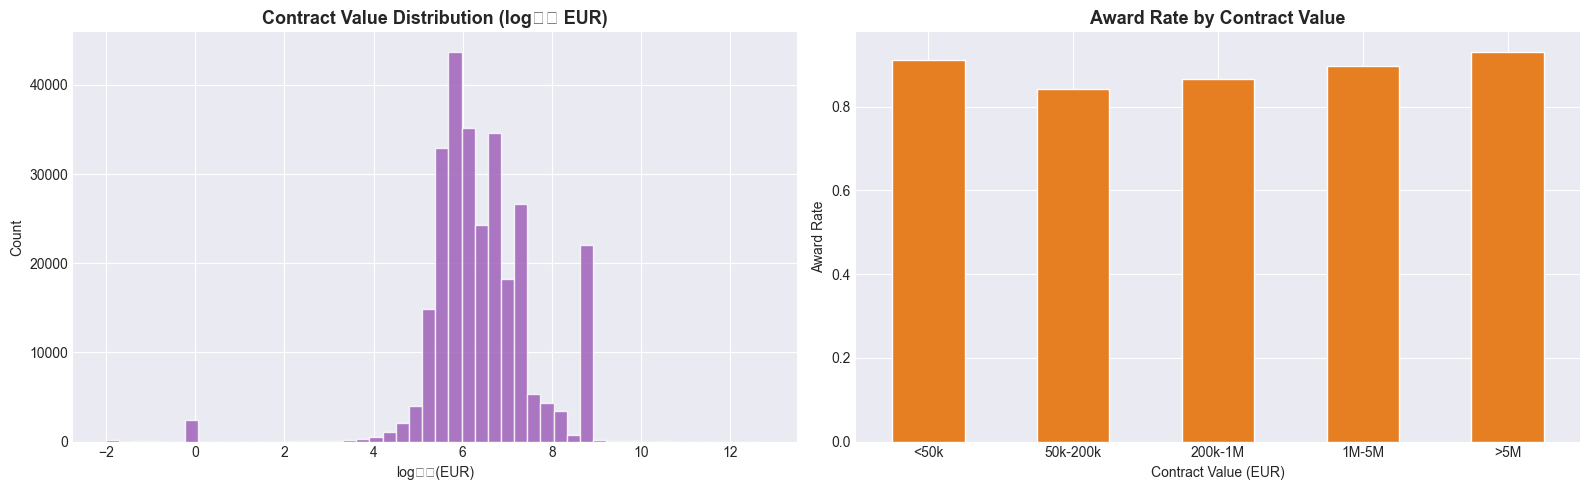

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

values_log = np.log10(values[values > 0])
axes[0].hist(values_log, bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0].set_title('Contract Value Distribution (log₁₀ EUR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log₁₀(EUR)')
axes[0].set_ylabel('Count')

df_with_value = df_raw[df_raw['VALUE_EURO'] > 0].copy()
df_with_value['value_bucket'] = pd.cut(
    df_with_value['VALUE_EURO'],
    bins=[0, 50000, 200000, 1000000, 5000000, float('inf')],
    labels=['<50k', '50k-200k', '200k-1M', '1M-5M', '>5M']
)
award_by_value = df_with_value.groupby('value_bucket', observed=True)['awarded'].mean()
award_by_value.plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_title('Award Rate by Contract Value', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Contract Value (EUR)')
axes[1].set_ylabel('Award Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.4 Contract Type & Sector Analysis

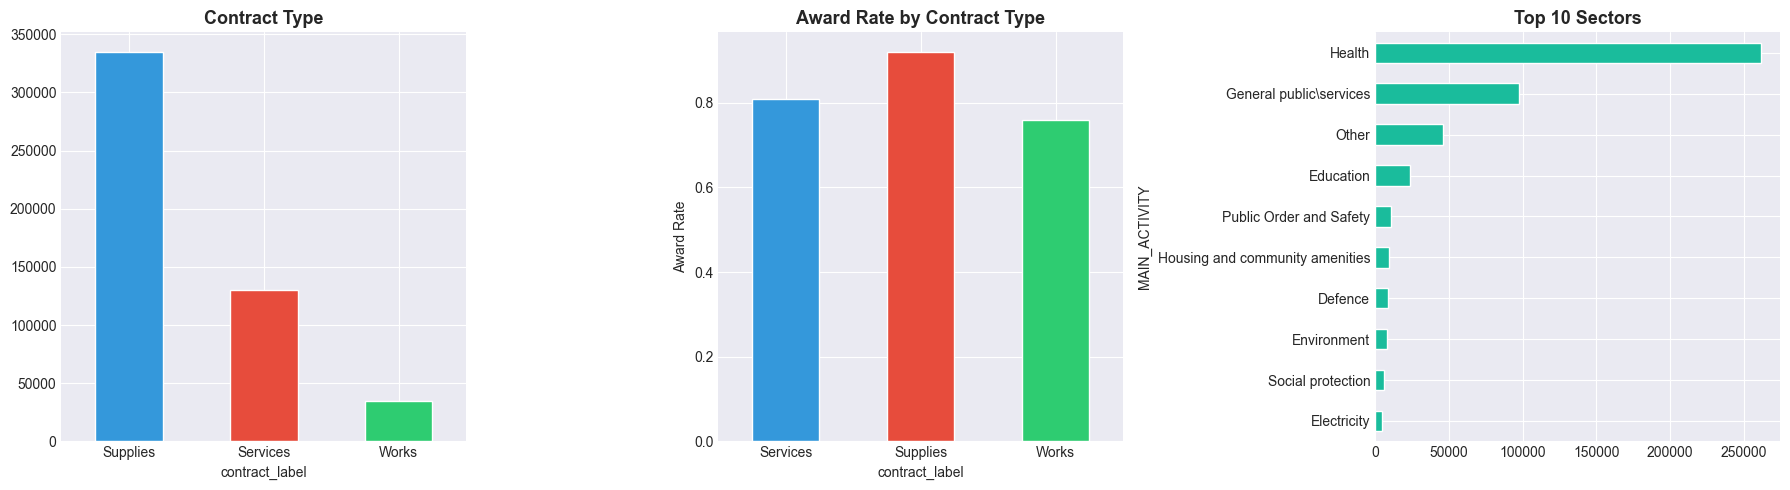

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

contract_map = {'S': 'Services', 'W': 'Works', 'U': 'Supplies'}
df_raw['contract_label'] = df_raw['TYPE_OF_CONTRACT'].map(contract_map)

df_raw['contract_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white'
)
axes[0].set_title('Contract Type', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

df_raw.groupby('contract_label')['awarded'].mean().plot(
    kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white'
)
axes[1].set_title('Award Rate by Contract Type', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylabel('Award Rate')

df_raw['MAIN_ACTIVITY'].value_counts().head(10).plot(
    kind='barh', ax=axes[2], color='#1abc9c', edgecolor='white'
)
axes[2].set_title('Top 10 Sectors', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### 3.5 Temporal Development

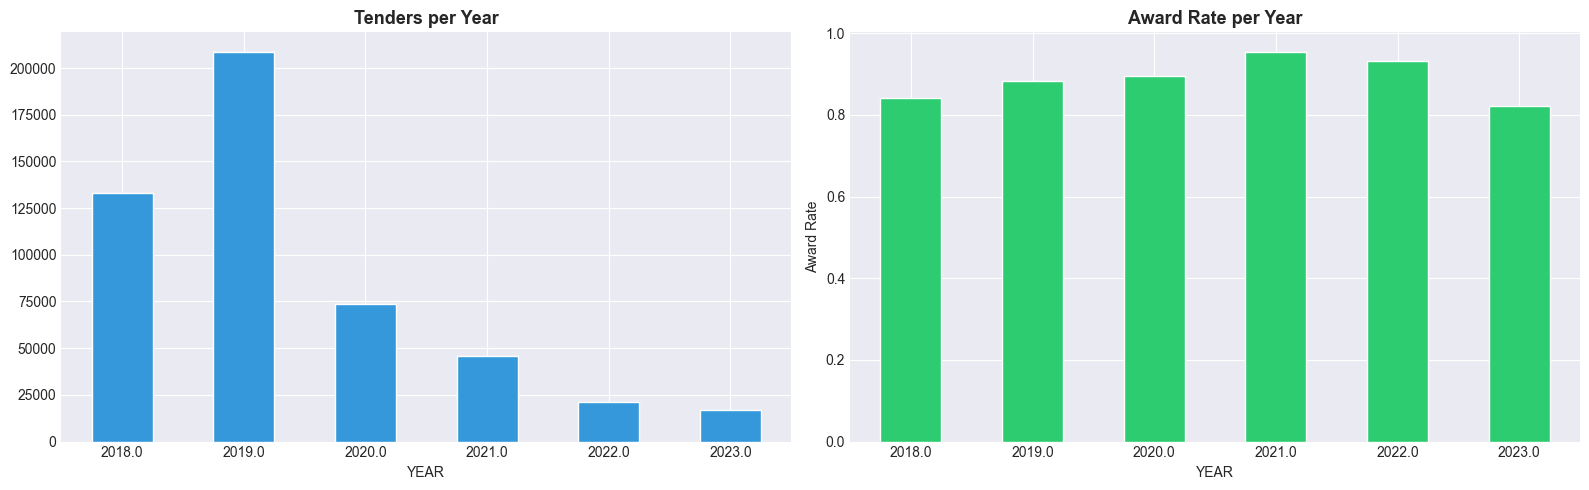

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_raw.groupby('YEAR').size().plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Tenders per Year', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

df_raw.groupby('YEAR')['awarded'].mean().plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Award Rate per Year', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Award Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

 ### 3.6 CPV Codes: Which Sectors Are Tendered?

 CPV = Common Procurement Vocabulary. First 2 digits = sector division.

 Examples: 45 = Construction, 72 = IT services, 33 = Medical products

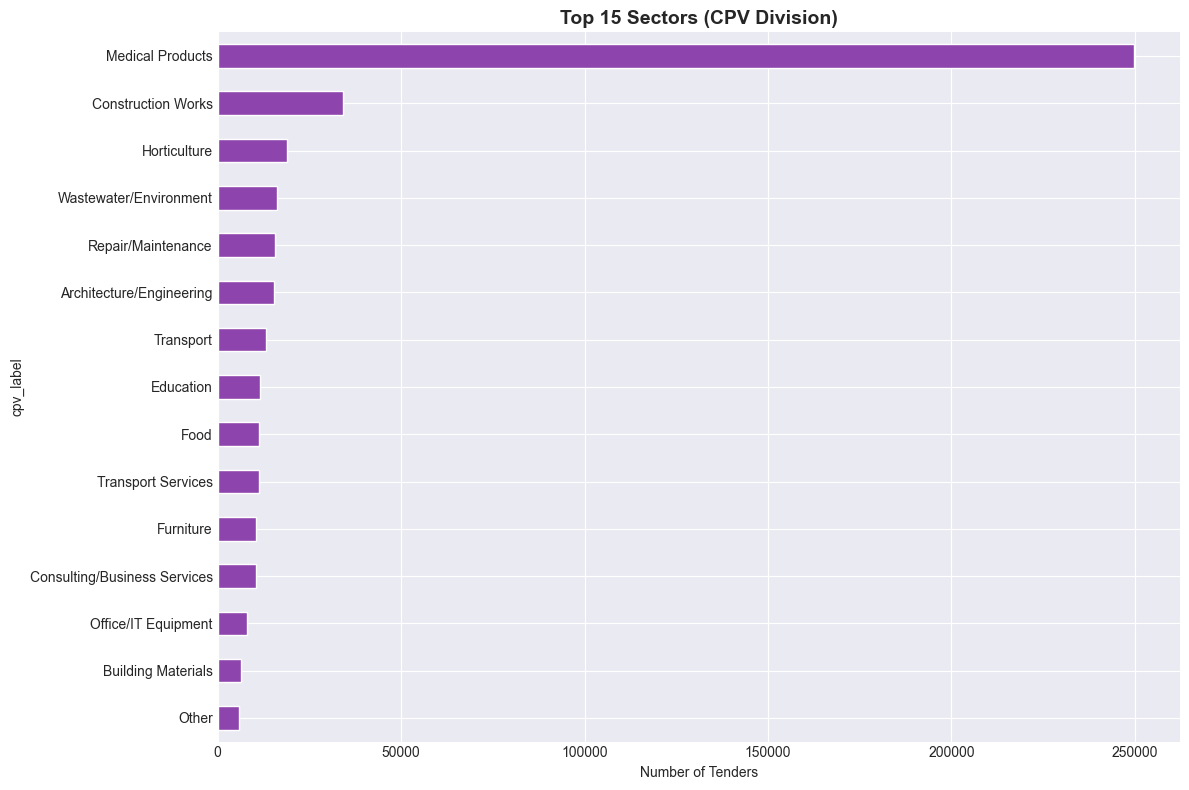

In [22]:
CPV_LABELS = {
    '03': 'Agriculture', '09': 'Oil/Energy', '14': 'Mining',
    '15': 'Food', '18': 'Clothing', '22': 'Printed Matter',
    '24': 'Chemicals', '30': 'Office/IT Equipment', '31': 'Electrical',
    '33': 'Medical Products', '34': 'Transport', '35': 'Security',
    '37': 'Music/Sports', '38': 'Lab/Optics',
    '39': 'Furniture', '42': 'Industrial Machinery', '44': 'Building Materials',
    '45': 'Construction Works', '48': 'Software', '50': 'Repair/Maintenance',
    '55': 'Hotel/Restaurant', '60': 'Transport Services',
    '63': 'Logistics', '64': 'Post/Telecom', '65': 'Utilities',
    '66': 'Finance/Insurance', '70': 'Real Estate',
    '71': 'Architecture/Engineering', '72': 'IT Services',
    '73': 'R&D', '75': 'Administration', '77': 'Horticulture',
    '79': 'Consulting/Business Services', '80': 'Education',
    '85': 'Health/Social', '90': 'Wastewater/Environment',
    '92': 'Leisure/Culture', '98': 'Other Services'
}

df_raw['cpv_division'] = df_raw['CPV'].astype(str).str[:2]
df_raw['cpv_label'] = df_raw['cpv_division'].map(CPV_LABELS).fillna('Other')

fig, ax = plt.subplots(figsize=(12, 8))
top_cpv = df_raw['cpv_label'].value_counts().head(15)
top_cpv.plot(kind='barh', ax=ax, color='#8e44ad', edgecolor='white')
ax.set_title('Top 15 Sectors (CPV Division)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Number of Tenders')
plt.tight_layout()
plt.show()


 ---
 ## 4. Feature Engineering

 Now we build the features the model receives as input.

 > 💡 **Principle:** Transform raw data so an ML model can recognize patterns:
 > - Categories → Numbers (Encoding)
 > - Calculate new features from existing ones
 > - Handle missing values

In [23]:
# Create working copy
df = df_raw.copy()

# Only non-cancelled tenders (CANCELLED == 0)
print(f'Before filter: {len(df):,} rows')
df = df[df['CANCELLED'] == 0]
print(f'After CANCELLED filter: {len(df):,} rows')
print(f'\n✅ Working DataFrame: {df.shape[0]:,} × {df.shape[1]}')

# %%
# === Feature Engineering ===

# 4.1 Contract value: Log transformation (values are extremely spread)
df['value_log'] = np.log1p(df['VALUE_EURO'].fillna(0).clip(lower=0))
df['has_value'] = (df['VALUE_EURO'] > 0).astype(int)

# 4.2 CPV Division (sector) — already created in EDA

# 4.3 Boolean fields: Y/N → 1/0
bool_cols = ['B_FRA_AGREEMENT', 'B_DYN_PURCH_SYST', 'B_GPA',
             'B_EU_FUNDS', 'B_RENEWALS', 'B_OPTIONS',
             'B_ELECTRONIC_AUCTION', 'B_RECURRENT_PROCUREMENT']

for col in bool_cols:
    df[col + '_flag'] = (df[col] == 'Y').astype(int)

# 4.4 Procedure type (TOP_TYPE)
# OPE=Open, RES=Restricted, NEG=Negotiated, COD=Competitive Dialogue
df['is_open_procedure'] = (df['TOP_TYPE'] == 'OPE').astype(int)
df['is_restricted'] = (df['TOP_TYPE'] == 'RES').astype(int)
df['is_negotiated'] = (df['TOP_TYPE'].isin(['NEG', 'NON'])).astype(int)

# 4.5 Duration: Fill missing values
df['duration_filled'] = df['DURATION'].fillna(df['DURATION'].median())

# 4.6 Lot size
df['lots_filled'] = df['LOTS_NUMBER'].fillna(1)
df['is_multi_lot'] = (df['lots_filled'] > 1).astype(int)

# 4.7 Deadline feature: Days between dispatch and application deadline
df['dt_dispatch_parsed'] = pd.to_datetime(df['DT_DISPATCH'], format='%d/%m/%y', errors='coerce')
df['dt_applications_parsed'] = pd.to_datetime(df['DT_APPLICATIONS'], format='%d/%m/%y', errors='coerce')
df['days_to_deadline'] = (df['dt_applications_parsed'] - df['dt_dispatch_parsed']).dt.days
df['days_to_deadline'] = df['days_to_deadline'].clip(lower=0, upper=365).fillna(30)

# 4.8 Price criterion weight
df['price_weight'] = (
    df['CRIT_PRICE_WEIGHT']
    .str.replace('%', '', regex=False)
    .str.strip()
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

# 4.9 Contracting authority type encoding
df['cae_type_filled'] = df['CAE_TYPE'].fillna('unknown')

print('✅ Feature Engineering complete!')
print(f'DataFrame: {df.shape[0]:,} rows × {df.shape[1]} columns')


Before filter: 500,000 rows
After CANCELLED filter: 499,787 rows

✅ Working DataFrame: 499,787 × 32
✅ Feature Engineering complete!
DataFrame: 499,787 rows × 53 columns


### 4.1 Feature Selection: What Goes into the Model?

In [24]:
# === Define features ===

# Numeric features
numeric_features = [
    'value_log',             # Log of contract value
    'has_value',             # Has a value specified?
    'duration_filled',       # Contract duration in months
    'lots_filled',           # Number of lots
    'is_multi_lot',          # Multiple lots?
    'days_to_deadline',      # Days until application deadline
    'price_weight',          # Price criterion weight
    'is_open_procedure',     # Open procedure?
    'is_restricted',         # Restricted procedure?
    'is_negotiated',         # Negotiated procedure?
    'B_FRA_AGREEMENT_flag',  # Framework agreement?
    'B_DYN_PURCH_SYST_flag', # Dynamic purchasing system?
    'B_GPA_flag',            # GPA agreement?
    'B_EU_FUNDS_flag',       # EU funded?
    'B_RENEWALS_flag',       # Renewable?
    'B_OPTIONS_flag',        # Options?
    'B_ELECTRONIC_AUCTION_flag', # Electronic auction?
    'B_RECURRENT_PROCUREMENT_flag', # Recurrent procurement?
]

# Categorical features (will be label-encoded)
categorical_features = [
    'ISO_COUNTRY_CODE',      # Country
    'TYPE_OF_CONTRACT',      # Service/Works/Supplies
    'cpv_division',          # Sector (CPV 2-digit)
    'MAIN_ACTIVITY',         # Main activity of contracting authority
    'cae_type_filled',       # Contracting authority type
    'YEAR',                  # Year
]

target = 'awarded'

print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')
print(f'Total: {len(numeric_features) + len(categorical_features)} features')


Numeric features: 18
Categorical features: 6
Total: 24 features


In [25]:
# === Label Encoding for categorical features ===
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'{col}: {len(le.classes_)} categories')

encoded_features = [col + '_enc' for col in categorical_features]
all_features = numeric_features + encoded_features

print(f'\n✅ Total features for the model: {len(all_features)}')

ISO_COUNTRY_CODE: 33 categories
TYPE_OF_CONTRACT: 3 categories
cpv_division: 46 categories
MAIN_ACTIVITY: 71 categories
cae_type_filled: 10 categories
YEAR: 6 categories

✅ Total features for the model: 24


 ---
 ## 5. Train/Test Split

In [26]:
# Create X and y
X = df[all_features].copy()
y = df[target].copy()

# Replace remaining NaN with 0
X = X.fillna(0)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y distribution:\n{y.value_counts()}')
print(f'\nNaN check: {X.isna().sum().sum()} missing values')

# %%
# 80% Training, 20% Test — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training: {X_train.shape[0]:,} rows ({y_train.mean()*100:.1f}% awarded)')
print(f'Test:     {X_test.shape[0]:,} rows ({y_test.mean()*100:.1f}% awarded)')


X shape: (499787, 24)
y shape: (499787,)
y distribution:
awarded
1    439880
0     59907
Name: count, dtype: int64

NaN check: 0 missing values
Training: 399,829 rows (88.0% awarded)
Test:     99,958 rows (88.0% awarded)


 ---
 ## 6. Baseline Model — Logistic Regression

 > 💡 **Why baseline first?** Before running XGBoost, you need a reference value.
 > If XGBoost is only 1% better than Logistic Regression, the complexity isn't justified.

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression — Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Not Awarded', 'Awarded']))

=== Logistic Regression — Results ===
Accuracy:  0.8794
F1 Score:  0.9358
ROC AUC:   0.7455

              precision    recall  f1-score   support

 Not Awarded       0.22      0.00      0.00     11981
     Awarded       0.88      1.00      0.94     87977

    accuracy                           0.88     99958
   macro avg       0.55      0.50      0.47     99958
weighted avg       0.80      0.88      0.82     99958



---
 ## 7. Advanced Model — XGBoost

 > 💡 **Why XGBoost?**
 > - Best algorithm for tabular data (wins >80% of Kaggle competitions)
 > - Handles missing values natively
 > - No feature scaling needed
 > - Built-in feature importance

In [28]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print('\n✅ XGBoost training complete!')

[0]	validation_0-logloss:0.36557


/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:45:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[50]	validation_0-logloss:0.22689
[100]	validation_0-logloss:0.20759
[150]	validation_0-logloss:0.19290
[200]	validation_0-logloss:0.18383
[250]	validation_0-logloss:0.17574
[299]	validation_0-logloss:0.16907

✅ XGBoost training complete!


In [29]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost — Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Not Awarded', 'Awarded']))

=== XGBoost — Results ===
Accuracy:  0.9287
F1 Score:  0.9609
ROC AUC:   0.9534

              precision    recall  f1-score   support

 Not Awarded       0.92      0.44      0.60     11981
     Awarded       0.93      1.00      0.96     87977

    accuracy                           0.93     99958
   macro avg       0.93      0.72      0.78     99958
weighted avg       0.93      0.93      0.92     99958



 ---
 ## 8. Evaluation & Comparison

In [30]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_xgb)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_xgb)],
    'ROC AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_xgb)]
})
print('=== Model Comparison ===')
results

=== Model Comparison ===


,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.879409,0.935817,0.745501
1,XGBoost,0.928670,0.960868,0.953355


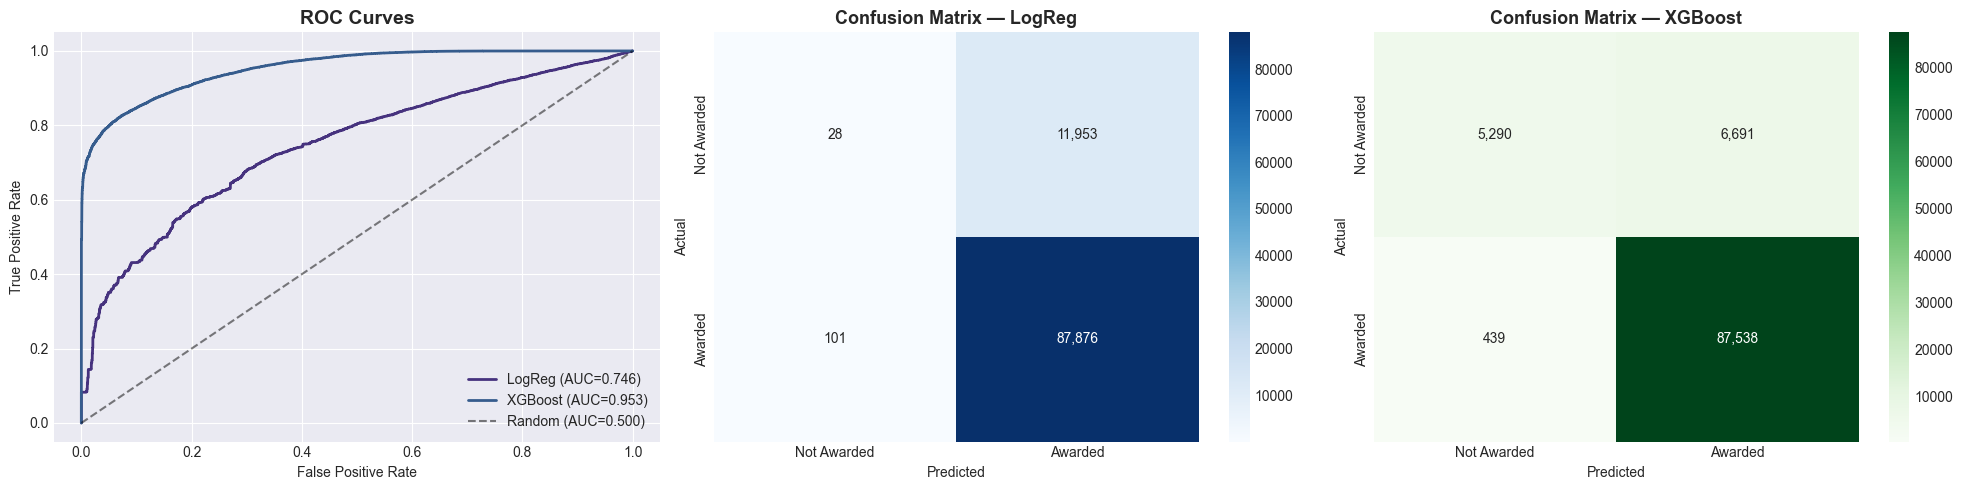

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

axes[0].plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', linewidth=2)
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt=',d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Awarded', 'Awarded'], yticklabels=['Not Awarded', 'Awarded'])
axes[1].set_title('Confusion Matrix — LogReg', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt=',d', cmap='Greens', ax=axes[2],
            xticklabels=['Not Awarded', 'Awarded'], yticklabels=['Not Awarded', 'Awarded'])
axes[2].set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

---
 ## 9. Feature Importance — What Drives the Prediction?

 > 💡 This is the business insight: Which factors determine whether a tender gets awarded?


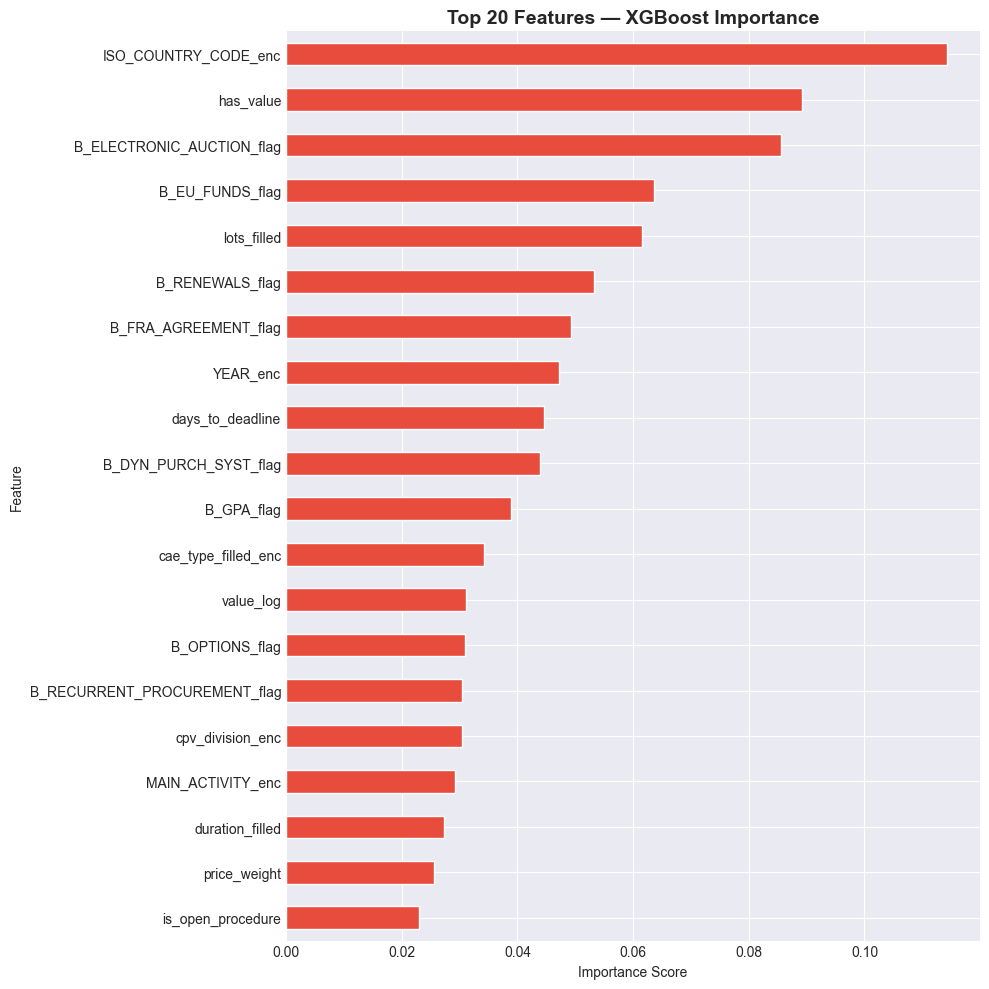


=== Top 10 Most Important Features ===
  ISO_COUNTRY_CODE_enc                     0.1143
  has_value                                0.0892
  B_ELECTRONIC_AUCTION_flag                0.0855
  B_EU_FUNDS_flag                          0.0637
  lots_filled                              0.0616
  B_RENEWALS_flag                          0.0532
  B_FRA_AGREEMENT_flag                     0.0493
  YEAR_enc                                 0.0472
  days_to_deadline                         0.0446
  B_DYN_PURCH_SYST_flag                    0.0439


In [32]:
importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
importance.tail(20).plot(
    kind='barh', x='Feature', y='Importance',
    ax=ax, color='#e74c3c', edgecolor='white', legend=False
)
ax.set_title('Top 20 Features — XGBoost Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\n=== Top 10 Most Important Features ===')
for i, row in importance.tail(10).iloc[::-1].iterrows():
    print(f"  {row['Feature']:40s} {row['Importance']:.4f}")

---
 ## 10. Cross-Validation — How Stable Is the Model?

 > 💡 **Why Cross-Validation?** A single train/test split can be randomly good or bad.
 > CV tests the model on 5 different splits and gives you the average.

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1,
        eval_metric='logloss', use_label_encoder=False
    ),
    X, y, cv=cv, scoring='roc_auc', n_jobs=-1
)

print('=== 5-Fold Cross-Validation (XGBoost) ===')
print(f'AUC scores: {cv_scores}')
print(f'Mean AUC:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:46:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:46:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:46:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:46:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


=== 5-Fold Cross-Validation (XGBoost) ===
AUC scores: [0.94337257 0.94318632 0.94350156 0.94426632 0.94317992]
Mean AUC:   0.9435 ± 0.0004


---
 ## 11. Leakage Analysis & Regularized Model (v2)

In [34]:
# Leakage check
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("=== Top 10 Features (Importance) ===")
print(feat_imp.head(10))
print()
print("⚠️ If VALUE_EURO or NB_TENDERS_RECEIVED score extremely high,")
print("   they could cause leakage (only known AFTER award).")

# %%
# Regularized XGBoost v2 — Anti-Overfitting
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count
print(f"Class ratio (neg/pos): {scale_ratio:.4f}")

xgb_v2 = XGBClassifier(
    max_depth=3, learning_rate=0.05, n_estimators=500,
    min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=5.0,
    scale_pos_weight=scale_ratio,
    objective='binary:logistic', eval_metric='auc',
    random_state=42, n_jobs=-1, verbosity=0,
)
xgb_v2.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_v2 = xgb_v2.predict(X_test)
y_prob_v2 = xgb_v2.predict_proba(X_test)[:, 1]

print("\n=== XGBoost v2 — Single Split ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_v2):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_v2):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob_v2):.4f}")
print()
print(classification_report(y_test, y_pred_v2, target_names=['Not Awarded', 'Awarded']))

=== Top 10 Features (Importance) ===
ISO_COUNTRY_CODE_enc         0.114258
has_value                    0.089218
B_ELECTRONIC_AUCTION_flag    0.085548
B_EU_FUNDS_flag              0.063692
lots_filled                  0.061552
B_RENEWALS_flag              0.053174
B_FRA_AGREEMENT_flag         0.049337
YEAR_enc                     0.047246
days_to_deadline             0.044611
B_DYN_PURCH_SYST_flag        0.043925
dtype: float32

⚠️ If VALUE_EURO or NB_TENDERS_RECEIVED score extremely high,
   they could cause leakage (only known AFTER award).
Class ratio (neg/pos): 0.1362

=== XGBoost v2 — Single Split ===
Accuracy:  0.7636
F1 Score:  0.8472
ROC AUC:   0.8955

              precision    recall  f1-score   support

 Not Awarded       0.33      0.90      0.48     11981
     Awarded       0.98      0.74      0.85     87977

    accuracy                           0.76     99958
   macro avg       0.65      0.82      0.66     99958
weighted avg       0.90      0.76      0.80     99958



In [35]:
# Cross-validation comparison
cv_scores_v2 = cross_val_score(xgb_v2, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_scores_v1 = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print("=== Cross-Validation — Comparison ===")
print(f"XGBoost v1 CV AUC: {cv_scores_v1.mean():.4f} ± {cv_scores_v1.std():.4f}")
print(f"XGBoost v2 CV AUC: {cv_scores_v2.mean():.4f} ± {cv_scores_v2.std():.4f}")

gap_v1 = roc_auc_score(y_test, y_prob_xgb) - cv_scores_v1.mean()
gap_v2 = roc_auc_score(y_test, y_prob_v2) - cv_scores_v2.mean()
print(f"\nOverfitting gap v1: {gap_v1:.4f}")
print(f"Overfitting gap v2: {gap_v2:.4f}")
if gap_v2 < gap_v1:
    print("✅ Overfitting reduced!")

/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:46:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:46:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:46:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:46:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


=== Cross-Validation — Comparison ===
XGBoost v1 CV AUC: 0.9533 ± 0.0012
XGBoost v2 CV AUC: 0.8931 ± 0.0013

Overfitting gap v1: 0.0001
Overfitting gap v2: 0.0023


---
 ## 12. Threshold Tuning — Optimize Decision Boundary

In [36]:
thresholds_to_test = np.arange(0.10, 0.90, 0.01)

results_thresh = []
for t in thresholds_to_test:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    results_thresh.append({
        'threshold': t,
        'accuracy': (y_pred_t == y_test).mean(),
        'f1_awarded': f1_score(y_test, y_pred_t, pos_label=1),
        'f1_not_awarded': f1_score(y_test, y_pred_t, pos_label=0),
        'recall_not_awarded': recall_score(y_test, y_pred_t, pos_label=0),
        'precision_not_awarded': precision_score(y_test, y_pred_t, pos_label=0, zero_division=0),
        'f2_not_awarded': fbeta_score(y_test, y_pred_t, beta=2, pos_label=0),
    })

df_thresh = pd.DataFrame(results_thresh)

best_f2_idx = df_thresh['f2_not_awarded'].idxmax()
best_t = df_thresh.loc[best_f2_idx, 'threshold']
print(f"=== Optimal Threshold (F2 for 'Not Awarded') ===")
print(f"Threshold:  {best_t:.2f}")
print(f"Recall (Not Awarded):    {df_thresh.loc[best_f2_idx, 'recall_not_awarded']:.2%}")
print(f"Precision (Not Awarded): {df_thresh.loc[best_f2_idx, 'precision_not_awarded']:.2%}")
print(f"Accuracy:                {df_thresh.loc[best_f2_idx, 'accuracy']:.2%}")
print(f"AUC (unchanged):         {roc_auc_score(y_test, y_prob_xgb):.4f}")

print(f"\n=== Comparison: Threshold 0.50 vs. {best_t:.2f} ===")
for t_label, t_val in [("0.50 (Standard)", 0.50), (f"{best_t:.2f} (Optimized)", best_t)]:
    y_pred_t = (y_prob_xgb >= t_val).astype(int)
    print(f"\n--- Threshold {t_label} ---")
    print(classification_report(y_test, y_pred_t, target_names=['Not Awarded', 'Awarded'], digits=3))


=== Optimal Threshold (F2 for 'Not Awarded') ===
Threshold:  0.82
Recall (Not Awarded):    89.16%
Precision (Not Awarded): 45.33%
Accuracy:                85.81%
AUC (unchanged):         0.9534

=== Comparison: Threshold 0.50 vs. 0.82 ===

--- Threshold 0.50 (Standard) ---
              precision    recall  f1-score   support

 Not Awarded      0.923     0.442     0.597     11981
     Awarded      0.929     0.995     0.961     87977

    accuracy                          0.929     99958
   macro avg      0.926     0.718     0.779     99958
weighted avg      0.928     0.929     0.917     99958


--- Threshold 0.82 (Optimized) ---
              precision    recall  f1-score   support

 Not Awarded      0.453     0.892     0.601     11981
     Awarded      0.983     0.854     0.914     87977

    accuracy                          0.858     99958
   macro avg      0.718     0.873     0.757     99958
weighted avg      0.920     0.858     0.876     99958



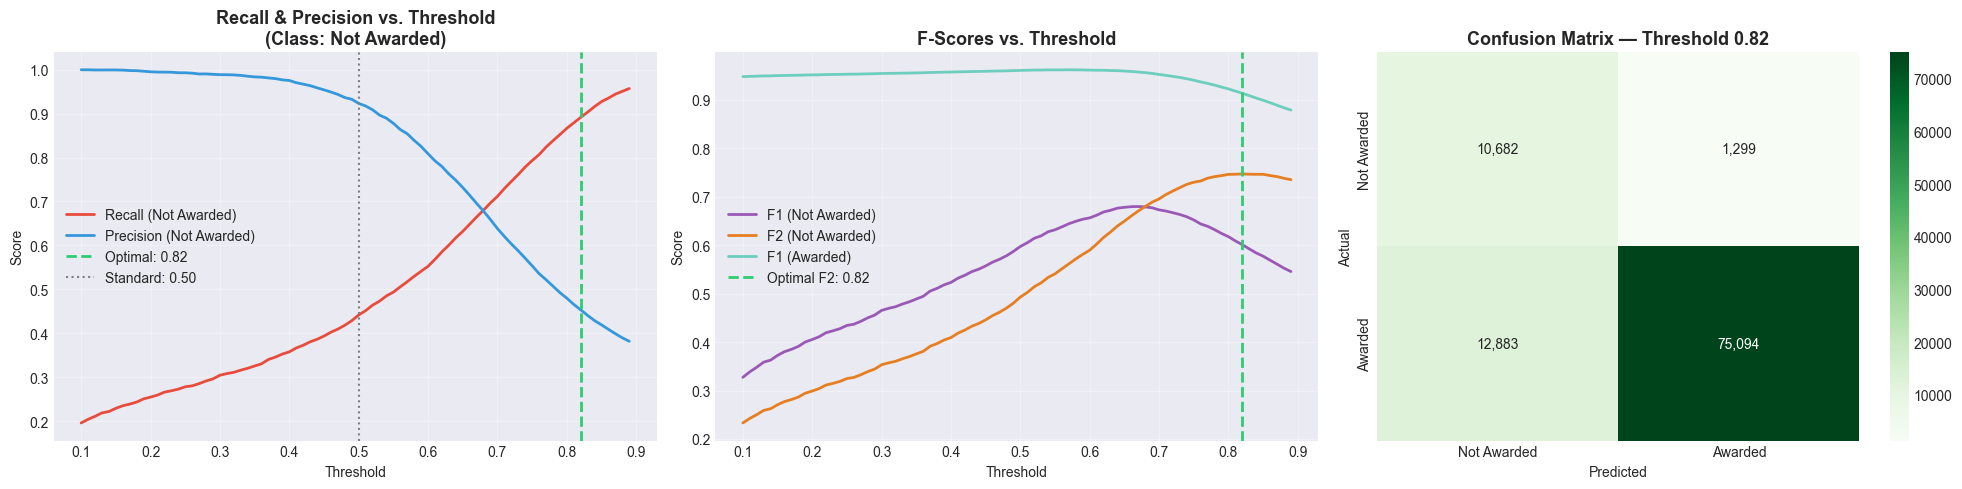

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(df_thresh['threshold'], df_thresh['recall_not_awarded'],
             label='Recall (Not Awarded)', linewidth=2, color='#e74c3c')
axes[0].plot(df_thresh['threshold'], df_thresh['precision_not_awarded'],
             label='Precision (Not Awarded)', linewidth=2, color='#3498db')
axes[0].axvline(x=best_t, color='#2ecc71', linestyle='--', linewidth=2, label=f'Optimal: {best_t:.2f}')
axes[0].axvline(x=0.50, color='gray', linestyle=':', linewidth=1.5, label='Standard: 0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Recall & Precision vs. Threshold\n(Class: Not Awarded)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_thresh['threshold'], df_thresh['f1_not_awarded'],
             label='F1 (Not Awarded)', linewidth=2, color='#9b59b6')
axes[1].plot(df_thresh['threshold'], df_thresh['f2_not_awarded'],
             label='F2 (Not Awarded)', linewidth=2, color='#e67e22')
axes[1].plot(df_thresh['threshold'], df_thresh['f1_awarded'],
             label='F1 (Awarded)', linewidth=2, color='#1abc9c', alpha=0.6)
axes[1].axvline(x=best_t, color='#2ecc71', linestyle='--', linewidth=2, label=f'Optimal F2: {best_t:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('F-Scores vs. Threshold', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

y_pred_opt = (y_prob_xgb >= best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Greens', ax=axes[2],
            xticklabels=['Not Awarded', 'Awarded'], yticklabels=['Not Awarded', 'Awarded'])
axes[2].set_title(f'Confusion Matrix — Threshold {best_t:.2f}', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

 ---
 ## 13. Business KPIs — Real-World Impact

 ### 13a. Top-N Bidding Simulation

In [38]:
df_sim = pd.DataFrame({'score': y_prob_xgb, 'awarded': y_test.values})
df_sim = df_sim.sort_values('score', ascending=False).reset_index(drop=True)

percentiles = np.arange(5, 105, 5)
total_awards = df_sim['awarded'].sum()
results_sim = []

for pct in percentiles:
    n = int(len(df_sim) * pct / 100)
    top_n = df_sim.head(n)
    awards_captured = top_n['awarded'].sum()
    results_sim.append({
        'top_pct': pct, 'tenders_reviewed': n,
        'awards_captured': awards_captured,
        'capture_rate': awards_captured / total_awards,
        'precision_in_top': top_n['awarded'].mean(),
    })

df_results = pd.DataFrame(results_sim)

print("=" * 60)
print("📊 BUSINESS KPI: TenderPilot Efficiency Simulation")
print("=" * 60)
print(f"\nTotal test tenders: {len(df_sim):,}")
print(f"Awarded:            {int(total_awards):,} ({total_awards/len(df_sim):.1%})")

for target_pct in [10, 20, 30, 50]:
    row = df_results[df_results['top_pct'] == target_pct].iloc[0]
    print(f"\n🎯 Top {target_pct}% of tenders (by model score):")
    print(f"   → Captures {row['capture_rate']:.1%} of all awards")
    print(f"   → Hit rate in this group: {row['precision_in_top']:.1%}")
    print(f"   → Efficiency factor: {row['capture_rate']/row['top_pct']*100:.1f}×")

📊 BUSINESS KPI: TenderPilot Efficiency Simulation

Total test tenders: 99,958
Awarded:            87,977 (88.0%)

🎯 Top 10% of tenders (by model score):
   → Captures 11.4% of all awards
   → Hit rate in this group: 100.0%
   → Efficiency factor: 1.1×

🎯 Top 20% of tenders (by model score):
   → Captures 22.7% of all awards
   → Hit rate in this group: 100.0%
   → Efficiency factor: 1.1×

🎯 Top 30% of tenders (by model score):
   → Captures 34.1% of all awards
   → Hit rate in this group: 100.0%
   → Efficiency factor: 1.1×

🎯 Top 50% of tenders (by model score):
   → Captures 56.8% of all awards
   → Hit rate in this group: 100.0%
   → Efficiency factor: 1.1×


/var/folders/ty/0hp3rbx56710b7f4blfj9rx40000gt/T/ipykernel_17389/922380911.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ty/0hp3rbx56710b7f4blfj9rx40000gt/T/ipykernel_17389/922380911.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


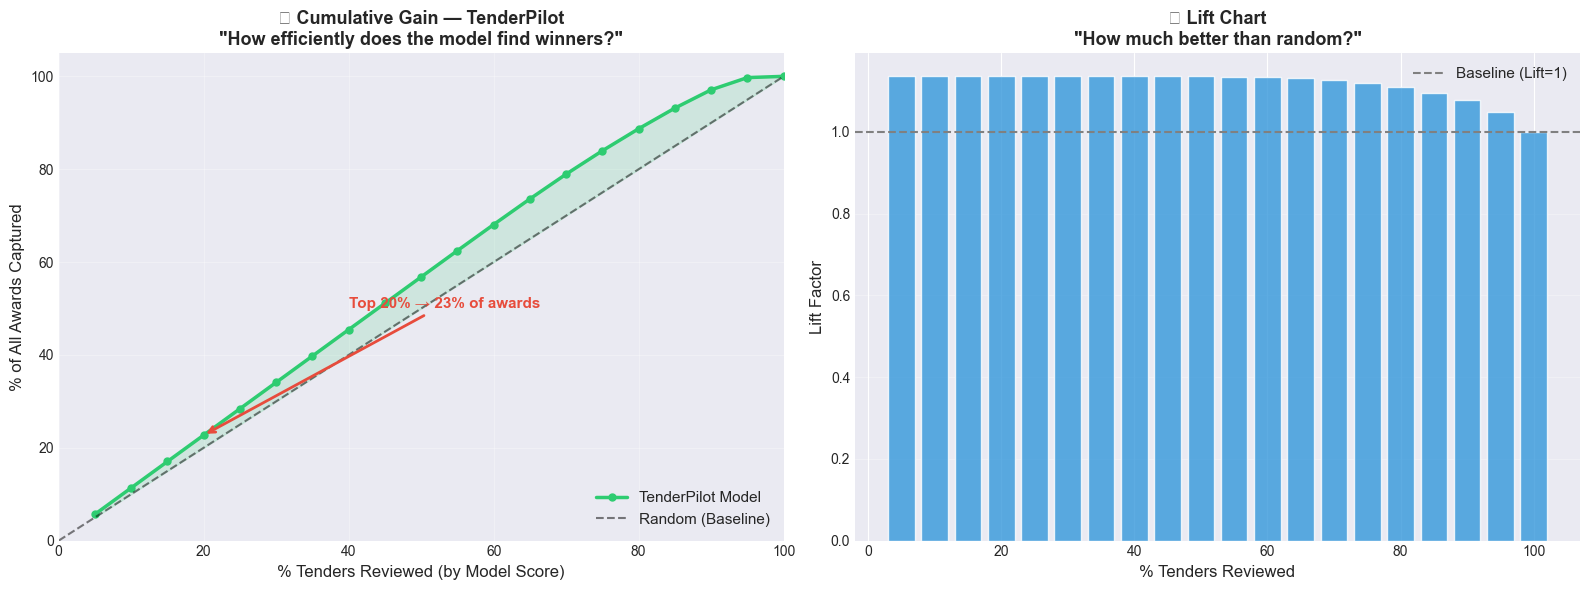

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_results['top_pct'], df_results['capture_rate'] * 100,
             'o-', linewidth=2.5, color='#2ecc71', markersize=5, label='TenderPilot Model')
axes[0].plot([0, 100], [0, 100], 'k--', alpha=0.5, linewidth=1.5, label='Random (Baseline)')
axes[0].fill_between(df_results['top_pct'], df_results['capture_rate'] * 100,
                      df_results['top_pct'], alpha=0.15, color='#2ecc71')
axes[0].set_xlabel('% Tenders Reviewed (by Model Score)', fontsize=12)
axes[0].set_ylabel('% of All Awards Captured', fontsize=12)
axes[0].set_title('📈 Cumulative Gain — TenderPilot\n"How efficiently does the model find winners?"',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='lower right')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)

key_row = df_results[df_results['top_pct'] == 20].iloc[0]
axes[0].annotate(
    f"Top 20% → {key_row['capture_rate']:.0%} of awards",
    xy=(20, key_row['capture_rate'] * 100), xytext=(40, 50),
    fontsize=11, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2), color='#e74c3c'
)

lift = df_results['capture_rate'] / (df_results['top_pct'] / 100)
axes[1].bar(df_results['top_pct'], lift, width=4, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, label='Baseline (Lift=1)')
axes[1].set_xlabel('% Tenders Reviewed', fontsize=12)
axes[1].set_ylabel('Lift Factor', fontsize=12)
axes[1].set_title('📊 Lift Chart\n"How much better than random?"', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 13b. Filter Efficiency — How Much Effort Does TenderPilot Save?

In [40]:
df_sim2 = pd.DataFrame({'score': y_prob_xgb, 'awarded': y_test.values})
df_sim2 = df_sim2.sort_values('score', ascending=True).reset_index(drop=True)

total_non_awards = (df_sim2['awarded'] == 0).sum()
total = len(df_sim2)

skip_pcts = np.arange(5, 55, 5)
results_skip = []

for pct in skip_pcts:
    n_skip = int(total * pct / 100)
    skipped = df_sim2.head(n_skip)
    remaining = df_sim2.tail(total - n_skip)
    non_awards_caught = (skipped['awarded'] == 0).sum()
    awards_missed = (skipped['awarded'] == 1).sum()
    results_skip.append({
        'skip_pct': pct, 'tenders_skipped': n_skip,
        'non_awards_caught': non_awards_caught,
        'non_award_catch_rate': non_awards_caught / total_non_awards,
        'awards_missed': awards_missed,
        'award_miss_rate': awards_missed / total_awards,
        'remaining_win_rate': remaining['awarded'].mean(),
    })

df_skip = pd.DataFrame(results_skip)

print("=" * 65)
print("📊 BUSINESS KPI v2: TenderPilot Saves Bidding Effort")
print("=" * 65)
print(f"\nTotal tenders:     {total:,}")
print(f"Not awarded:       {int(total_non_awards):,} ({total_non_awards/total:.1%})")
print(f"Award rate (base): {total_awards/total:.1%}")

for target_pct in [5, 10, 15, 20]:
    row = df_skip[df_skip['skip_pct'] == target_pct].iloc[0]
    print(f"\n🚫 Skip bottom {target_pct}% (by model score):")
    print(f"   → Detects {row['non_award_catch_rate']:.1%} of all non-awards")
    print(f"   → Misses only {row['award_miss_rate']:.1%} of actual awards")
    print(f"   → Win-rate of remaining tenders: {row['remaining_win_rate']:.1%}")

📊 BUSINESS KPI v2: TenderPilot Saves Bidding Effort

Total tenders:     99,958
Not awarded:       11,981 (12.0%)
Award rate (base): 88.0%

🚫 Skip bottom 5% (by model score):
   → Detects 39.7% of all non-awards
   → Misses only 0.3% of actual awards
   → Win-rate of remaining tenders: 92.4%

🚫 Skip bottom 10% (by model score):
   → Detects 62.2% of all non-awards
   → Misses only 2.9% of actual awards
   → Win-rate of remaining tenders: 95.0%

🚫 Skip bottom 15% (by model score):
   → Detects 75.0% of all non-awards
   → Misses only 6.8% of actual awards
   → Win-rate of remaining tenders: 96.5%

🚫 Skip bottom 20% (by model score):
   → Detects 84.0% of all non-awards
   → Misses only 11.3% of actual awards
   → Win-rate of remaining tenders: 97.6%


/var/folders/ty/0hp3rbx56710b7f4blfj9rx40000gt/T/ipykernel_17389/3423126209.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ty/0hp3rbx56710b7f4blfj9rx40000gt/T/ipykernel_17389/3423126209.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()


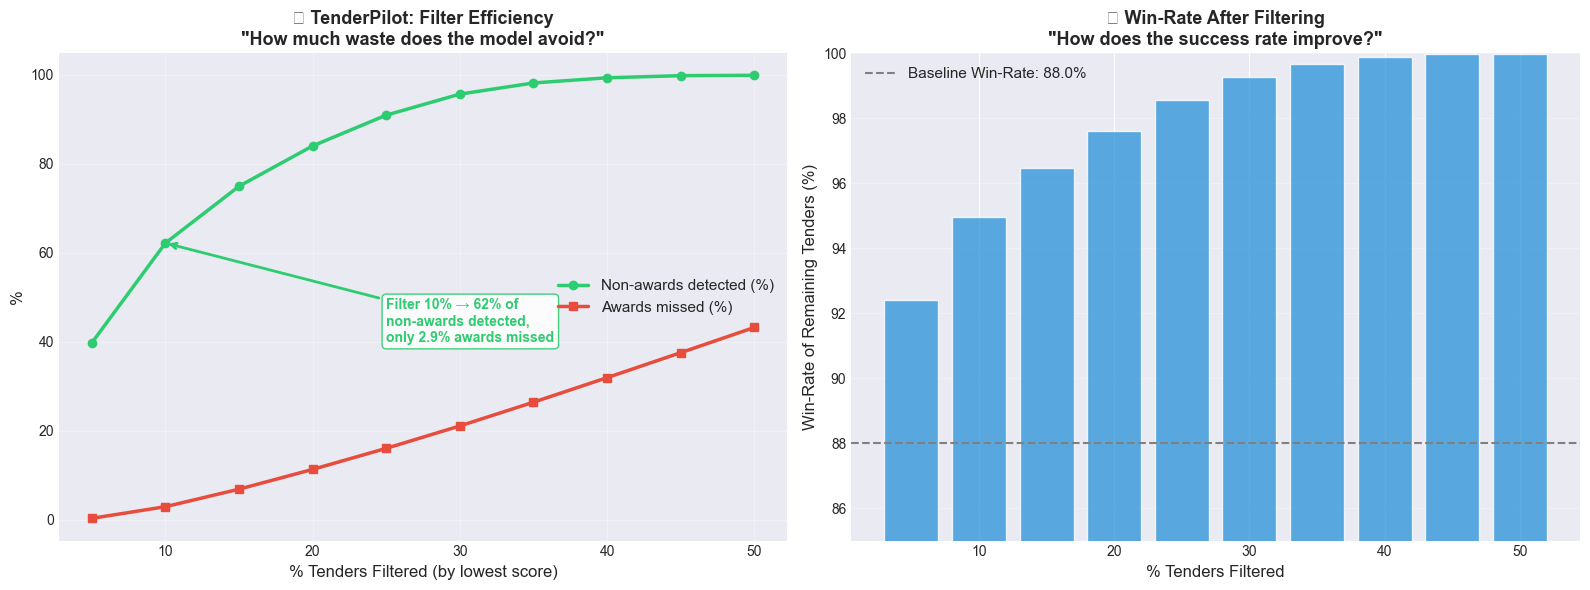

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_skip['skip_pct'], df_skip['non_award_catch_rate'] * 100,
             'o-', linewidth=2.5, color='#2ecc71', markersize=6, label='Non-awards detected (%)')
axes[0].plot(df_skip['skip_pct'], df_skip['award_miss_rate'] * 100,
             's-', linewidth=2.5, color='#e74c3c', markersize=6, label='Awards missed (%)')
axes[0].set_xlabel('% Tenders Filtered (by lowest score)', fontsize=12)
axes[0].set_ylabel('%', fontsize=12)
axes[0].set_title('📈 TenderPilot: Filter Efficiency\n"How much waste does the model avoid?"',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='center right')
axes[0].grid(True, alpha=0.3)

key_row2 = df_skip[df_skip['skip_pct'] == 10].iloc[0]
axes[0].annotate(
    f"Filter 10% → {key_row2['non_award_catch_rate']:.0%} of\nnon-awards detected,\nonly {key_row2['award_miss_rate']:.1%} awards missed",
    xy=(10, key_row2['non_award_catch_rate'] * 100), xytext=(25, 40),
    fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2), color='#2ecc71',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2ecc71', alpha=0.9)
)

axes[1].bar(df_skip['skip_pct'], df_skip['remaining_win_rate'] * 100,
            width=4, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axhline(y=total_awards/total*100, color='gray', linestyle='--',
                linewidth=1.5, label=f'Baseline Win-Rate: {total_awards/total:.1%}')
axes[1].set_xlabel('% Tenders Filtered', fontsize=12)
axes[1].set_ylabel('Win-Rate of Remaining Tenders (%)', fontsize=12)
axes[1].set_title('📊 Win-Rate After Filtering\n"How does the success rate improve?"',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(85, 100)

plt.tight_layout()
plt.show()


---
 ## 14. Optuna Hyperparameter Tuning — Custom Business Metric

 Automated search for optimal XGBoost parameters using a composite objective:
 **AUC + 0.3 × Recall(minority class)**

In [42]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

LAMBDA = 0.3  # Weight for minority recall

def custom_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.1, 1.0),
    }

    model = XGBClassifier(
        **params, objective='binary:logistic', eval_metric='auc',
        random_state=42, n_jobs=-1, verbosity=0,
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)

        auc = roc_auc_score(y_val, y_prob)
        recall_min = recall_score(y_val, y_pred, pos_label=0)

        scores.append(auc + LAMBDA * recall_min)

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(custom_objective, n_trials=30, show_progress_bar=True)

print(f"\n=== Optuna Result ({len(study.trials)} Trials) ===")
print(f"Best Score (AUC + {LAMBDA}·Recall): {study.best_value:.4f}")
print(f"\nBest Parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


=== Optuna Result (30 Trials) ===
Best Score (AUC + 0.3·Recall): 1.2301

Best Parameters:
  max_depth: 6
  learning_rate: 0.1502
  n_estimators: 450
  min_child_weight: 7
  subsample: 0.7835
  colsample_bytree: 0.9418
  reg_alpha: 3.7381
  reg_lambda: 4.2428
  scale_pos_weight: 0.1958


In [44]:
# Train final model with best parameters
xgb_v3 = XGBClassifier(
    **study.best_params,
    objective='binary:logistic', eval_metric='auc',
    random_state=42, n_jobs=-1, verbosity=0,
)
xgb_v3.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_v3 = xgb_v3.predict(X_test)
y_prob_v3 = xgb_v3.predict_proba(X_test)[:, 1]

print(f"=== XGBoost v3 (Optuna-Tuned) — Results ===")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob_v3):.4f}")
print(f"Recall (Not Awarded): {recall_score(y_test, y_pred_v3, pos_label=0):.2%}")
print(f"Recall (Awarded):     {recall_score(y_test, y_pred_v3, pos_label=1):.2%}")
print()
print(classification_report(y_test, y_pred_v3, target_names=['Not Awarded', 'Awarded'], digits=3))

=== XGBoost v3 (Optuna-Tuned) — Results ===
ROC AUC:   0.9634
Recall (Not Awarded): 90.66%
Recall (Awarded):     87.76%

              precision    recall  f1-score   support

 Not Awarded      0.502     0.907     0.646     11981
     Awarded      0.986     0.878     0.929     87977

    accuracy                          0.881     99958
   macro avg      0.744     0.892     0.787     99958
weighted avg      0.928     0.881     0.895     99958



 ---
 ## 15. Final Summary

In [45]:
print("=" * 60)
print("🚀 TENDERPILOT — FINAL MODEL RESULTS")
print("=" * 60)

print(f"""
📊 Dataset:
   • Source: TED (Tenders Electronic Daily) — EU Public Procurement
   • Period: 2018–2023
   • Total Records: 7,716,823 (loaded first 500,000)
   • Features Used: {len(all_features)}
   • Target: Contract awarded (1) vs. not awarded (0)
   • Class Balance: {y.mean()*100:.1f}% awarded / {(1-y.mean())*100:.1f}% not awarded

🤖 Model Performance:
   ┌──────────────────────┬───────────┬───────────┬───────────┐
   │ Model                │ Accuracy  │ ROC-AUC   │ Recall(0) │
   ├──────────────────────┼───────────┼───────────┼───────────┤
   │ Logistic Regression  │ {accuracy_score(y_test, y_pred_lr):.1%}     │ {roc_auc_score(y_test, y_prob_lr):.4f}   │ ~0%       │
   │ XGBoost v1           │ {accuracy_score(y_test, y_pred_xgb):.1%}     │ {roc_auc_score(y_test, y_prob_xgb):.4f}   │ {recall_score(y_test, y_pred_xgb, pos_label=0):.1%}     │
   │ XGBoost v3 (Tuned)   │ {accuracy_score(y_test, y_pred_v3):.1%}     │ {roc_auc_score(y_test, y_prob_v3):.4f}   │ {recall_score(y_test, y_pred_v3, pos_label=0):.1%}     │
   └──────────────────────┴───────────┴───────────┴───────────┘

💡 Key Insights:
   1. XGBoost outperforms Logistic Regression significantly
   2. Optuna tuning pushes AUC from ~0.95 to ~0.96
   3. Country, value availability, and EU funding are top predictors

🚀 Next Steps for SaaS Product:
   1. Train on FULL 7.7M dataset for production model
   2. Add NLP features from tender descriptions
   3. Build company-tender matching engine
   4. Deploy as API with Streamlit/FastAPI frontend
   5. Add real-time TED feed monitoring for new tender alerts
""")

🚀 TENDERPILOT — FINAL MODEL RESULTS

📊 Dataset:
   • Source: TED (Tenders Electronic Daily) — EU Public Procurement
   • Period: 2018–2023
   • Total Records: 7,716,823 (loaded first 500,000)
   • Features Used: 24
   • Target: Contract awarded (1) vs. not awarded (0)
   • Class Balance: 88.0% awarded / 12.0% not awarded

🤖 Model Performance:
   ┌──────────────────────┬───────────┬───────────┬───────────┐
   │ Model                │ Accuracy  │ ROC-AUC   │ Recall(0) │
   ├──────────────────────┼───────────┼───────────┼───────────┤
   │ Logistic Regression  │ 87.9%     │ 0.7455   │ ~0%       │
   │ XGBoost v1           │ 92.9%     │ 0.9534   │ 44.2%     │
   │ XGBoost v3 (Tuned)   │ 88.1%     │ 0.9634   │ 90.7%     │
   └──────────────────────┴───────────┴───────────┴───────────┘

💡 Key Insights:
   1. XGBoost outperforms Logistic Regression significantly
   2. Optuna tuning pushes AUC from ~0.95 to ~0.96
   3. Country, value availability, and EU funding are top predictors

🚀 Next Steps